In [ ]:
import os
import pickle
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from keras.applications.resnet50 import ResNet50, preprocess_input
from keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.preprocessing import sequence

from tensorflow.keras.layers import Input, Dense, Embedding, LayerNormalization, MultiHeadAttention
from tensorflow.keras.models import Model
from tensorflow.keras.metrics import top_k_categorical_accuracy

from IPython.display import Image

In [11]:
!wget https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_Dataset.zip
!wget https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_text.zip
!unzip Flickr8k_Dataset.zip
!unzip Flickr8k_text.zip

Streaming output truncated to the last 5000 lines.
  inflating: __MACOSX/Flicker8k_Dataset/._3429391520_930b153f94.jpg  
  inflating: Flicker8k_Dataset/3429465163_fb8ac7ce7f.jpg  
  inflating: __MACOSX/Flicker8k_Dataset/._3429465163_fb8ac7ce7f.jpg  
  inflating: Flicker8k_Dataset/3429581486_4556471d1a.jpg  
  inflating: __MACOSX/Flicker8k_Dataset/._3429581486_4556471d1a.jpg  
  inflating: Flicker8k_Dataset/3429641260_2f035c1813.jpg  
  inflating: __MACOSX/Flicker8k_Dataset/._3429641260_2f035c1813.jpg  
  inflating: Flicker8k_Dataset/3429956016_3c7e3096c2.jpg  
  inflating: __MACOSX/Flicker8k_Dataset/._3429956016_3c7e3096c2.jpg  
  inflating: Flicker8k_Dataset/3430100177_5864bf1e73.jpg  
  inflating: __MACOSX/Flicker8k_Dataset/._3430100177_5864bf1e73.jpg  
  inflating: Flicker8k_Dataset/3430287726_94a1825bbf.jpg  
  inflating: __MACOSX/Flicker8k_Dataset/._3430287726_94a1825bbf.jpg  
  inflating: Flicker8k_Dataset/3430526230_234b3550f6.jpg  
  inflating: __MACOSX/Flicker8k_Dataset/._3430

In [2]:
OUTPUT_DIR = os.path.join("Outputs")
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

In [18]:
IMAGES_DIR = os.path.join("Flicker8k_Dataset/")
CAPTIONS_FILE = os.path.join("Flickr8k.token.txt")
TRAIN_IDS_FILE = os.path.join("Flickr_8k.trainImages.txt")
VAL_IDS_FILE = os.path.join("Flickr_8k.devImages.txt")
TEST_IDS_FILE = os.path.join("Flickr_8k.testImages.txt")

TRAIN_DATASET_FILE = os.path.join(OUTPUT_DIR, "flickr_8k_train_dataset.txt")
VAL_DATASET_FILE = os.path.join(OUTPUT_DIR, "flickr_8k_val_dataset.txt")
TEST_DATASET_FILE = os.path.join(OUTPUT_DIR, "flickr_8k_test_dataset.txt")

In [ ]:
def load_image_ids(file_path):
    with open(file_path, 'r') as f:
        image_ids = f.read().strip().split("\n")
    return [img for img in image_ids if img]

def load_captions(captions_file):
    tokens = {}
    with open(captions_file, 'r') as f:
        lines = f.read().strip().split("\n")
    for line in lines:
        parts = line.split("#")
        if len(parts) < 2:
            continue
        image_id = parts[0]
        caption = parts[1].strip()[2:]
        tokens.setdefault(image_id, []).append(caption)
    return tokens

train_ids = load_image_ids(TRAIN_IDS_FILE)
val_ids   = load_image_ids(VAL_IDS_FILE)
test_ids  = load_image_ids(TEST_IDS_FILE)
caption_tokens = load_captions(CAPTIONS_FILE)

In [ ]:
def write_dataset_file(image_ids, tokens, output_file):
    with open(output_file, 'wb') as f:
        header = "image_id\tcaptions\n"
        f.write(header.encode())
        for img in image_ids:
            if img not in tokens:
                continue
            for capt in tokens[img]:
                caption = "<start> " + capt + " <end>"
                f.write(f"{img}\t{caption}\n".encode())
                f.flush()

write_dataset_file(train_ids, caption_tokens, TRAIN_DATASET_FILE)
write_dataset_file(val_ids, caption_tokens, VAL_DATASET_FILE)
write_dataset_file(test_ids, caption_tokens, TEST_DATASET_FILE)

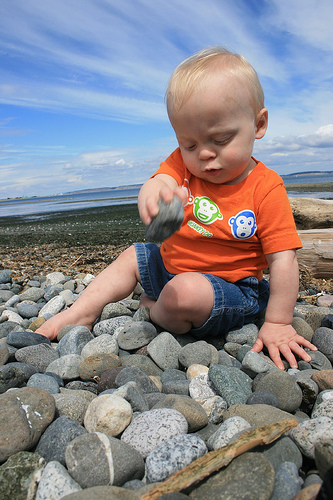

Captions for image: 1112212364_0c48235fc2.jpg
A baby is sitting on and playing with smooth rocks .
A baby is stacking rocks on the beach .
A small boy is playing with rocks
A toddler sitting on a pile of rocks holding a rock at a beach .
Toddler sits on a pile of rocks .


In [ ]:
sample_img_id = list(caption_tokens.keys())[101]
display(Image(filename=os.path.join(IMAGES_DIR, sample_img_id)))
print("Captions for image:", sample_img_id)
for cap in caption_tokens[sample_img_id]:
    print(cap)

In [ ]:
def preprocess_image(img_path, target_size=(224, 224)):
    im = image.load_img(img_path, target_size=target_size)
    im = image.img_to_array(im)
    im = preprocess_input(im)
    im = np.expand_dims(im, axis=0)
    return im

def get_image_encoding(resnet_model, img_path):
    img = preprocess_image(img_path)
    features = resnet_model.predict(img).reshape(2048)
    return features

def extract_features_for_images(image_ids, images_dir, resnet_model, limit=None, augment=False, num_augmented=5):
    features_dict = {}
    count = 0
    if augment:
        datagen = ImageDataGenerator(
            rotation_range=30,
            width_shift_range=0.2,
            height_shift_range=0.2,
            shear_range=0.15,
            zoom_range=0.2,
            horizontal_flip=True,
            fill_mode='nearest',
            preprocessing_function=preprocess_input
        )
    for img_id in image_ids:
        if limit is not None and count >= limit:
            break
        count += 1
        if count % 1000 == 0:
            print(f"Processed {count} images")
        img_path = os.path.join(images_dir, img_id)
        img = image.load_img(img_path, target_size=(224, 224))
        x = image.img_to_array(img)
        x = np.expand_dims(x, axis=0)
        if augment:
            aug_features = []
            aug_iter = datagen.flow(x, batch_size=1)
            for i in range(num_augmented):
                aug_img = next(aug_iter)
                feature = resnet_model.predict(aug_img).reshape(-1)
                aug_features.append(feature)
            avg_feature = np.mean(aug_features, axis=0)
            features_dict[img_id] = avg_feature
        else:
            feature = resnet_model.predict(x).reshape(-1)
            features_dict[img_id] = feature
    return features_dict

In [27]:
resnet_model = ResNet50(include_top=False, weights='imagenet', input_shape=(224, 224, 3), pooling='avg')
resnet_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 224, 224, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_pad (ZeroPadding2D) │ (None, 230, 230, 3)    │              0 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 112, 112, 64)   │          9,472 │ conv1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 112, 112, 64)   │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 112, 112, 64)   │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pad (ZeroPadding2D) │ (None, 114, 114, 64)   │              0 │ conv1_relu[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pool (MaxPooling2D) │ (None, 56, 56, 64)     │              0 │ pool1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 56, 56, 64)     │          4,160 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 56, 56, 64)     │         36,928 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_2_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_2_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_conv       │ (None, 56, 56, 256)    │         16,640 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_3_conv       │ (None, 56, 56, 256)    │         16,640 │ conv2_block1_2_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├──────────────────────

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [ ]:
train_features = extract_features_for_images(train_ids, IMAGES_DIR, resnet_model, limit=3000, augment=True, num_augmented=2)
with open(os.path.join(OUTPUT_DIR, "train_encoded_images.pkl"), "wb") as f:
    pickle.dump(train_features, f)

1/1 [==============================] - 0s 458ms/step
Processed 1000 images
1/1 [==============================] - 1s 519ms/step
Processed 2000 images
1/1 [==============================] - 1s 748ms/step
Processed 3000 images
1/1 [==============================] - 1s 762ms/step


In [ ]:
val_features = extract_features_for_images(val_ids, IMAGES_DIR, resnet_model, augment=False)
with open(os.path.join(OUTPUT_DIR, "val_encoded_images.pkl"), "wb") as f:
    pickle.dump(val_features, f)

1/1 [==============================] - 4s 4s/step
Processed 1000 images
1/1 [==============================] - 4s 4s/step


In [ ]:
test_features = extract_features_for_images(test_ids, IMAGES_DIR, resnet_model, augment=False)
with open(os.path.join(OUTPUT_DIR, "test_encoded_images.pkl"), "wb") as f:
    pickle.dump(test_features, f)

1/1 [==============================] - 3s 3s/step
Processed 1000 images
1/1 [==============================] - 3s 3s/step


In [21]:
df_train = pd.read_csv(TRAIN_DATASET_FILE, delimiter='\t')
ds = df_train.values
print("Dataset shape:", ds.shape)

Dataset shape: (30000, 2)


In [22]:
sentences = ds[:, 1].tolist()
print("Total Number of Captions :", len(sentences))
print("First 5 Captions :", sentences[:5])

Total Number of Captions : 30000
First 5 Captions : ['<start> A black dog is running after a white dog in the snow . <end>', '<start> Black dog chasing brown dog through snow <end>', '<start> Two dogs chase each other across the snowy ground . <end>', '<start> Two dogs play together in the snow . <end>', '<start> Two dogs running through a low lying body of water . <end>']


In [23]:
unique_words = set(word for sentence in sentences for word in sentence.split())
unique_words = list(unique_words)
print("Vocabulary size (raw):", len(unique_words))

Vocabulary size (raw): 8253


In [ ]:
word2index = {word: idx for idx, word in enumerate(unique_words)}
index2word = {idx: word for idx, word in enumerate(unique_words)}

word2index['UNK'] = 0
index2word[0] = 'UNK'
word2index['raining'] = 8253
index2word[8253] = 'raining'

vocab_size = len(word2index.keys())
print("Final vocabulary size:", vocab_size)

Final vocabulary size: 8254


In [ ]:
with open(os.path.join(OUTPUT_DIR, "word_2_indices.pkl"), "wb") as f:
    pickle.dump(word2index, f)
with open(os.path.join(OUTPUT_DIR, "indices_2_word.pkl"), "wb") as f:
    pickle.dump(index2word, f)

In [ ]:
max_len_train = max(len(sentence.split()) for sentence in sentences)
print("Maximum Caption Length (Training) :", max_len_train)

Maximum Caption Length (Training) : 40


In [ ]:
def create_sequences(ds, word2index, max_len):
    padded_sequences, next_words = [], []
    for i in range(ds.shape[0]):
        caption = ds[i, 1]
        words = caption.split()
        indices = [word2index.get(word, word2index['UNK']) for word in words]
        partial_seqs = []
        next_w = []
        for j in range(1, len(indices)):
            partial_seqs.append(indices[:j])
            next_w.append(indices[j])
        padded_seq = sequence.pad_sequences(partial_seqs, maxlen=max_len, padding='post')
        one_hot = np.zeros((len(next_w), len(word2index)), dtype=bool)
        for j, idx in enumerate(next_w):
            one_hot[j, idx] = 1
        padded_sequences.append(padded_seq)
        next_words.append(one_hot)
    return np.array(padded_sequences, dtype=object), np.array(next_words, dtype=object)

MAX_LEN = 40
padded_sequences, subsequent_words = create_sequences(ds, word2index, MAX_LEN)
print("Shape of padded sequences (per image):", padded_sequences[0].shape)
print("Shape of subsequent words (per image):", subsequent_words[0].shape)

Shape of padded sequences (per image): (14, 40)
Shape of subsequent words (per image): (14, 8254)


In [ ]:
num_train_images = 3000
captions_arr = np.zeros([0, padded_sequences[0].shape[1]])
next_words_arr = np.zeros([0, vocab_size])
for i in range(num_train_images):
    captions_arr = np.concatenate([captions_arr, padded_sequences[i]])
    next_words_arr = np.concatenate([next_words_arr, subsequent_words[i]])

np.save(os.path.join(OUTPUT_DIR, "captions.npy"), captions_arr)
np.save(os.path.join(OUTPUT_DIR, "next_words.npy"), next_words_arr)
print("Training captions shape:", captions_arr.shape)
print("Training next words shape:", next_words_arr.shape)

Training captions shape: (38161, 40)
Training next words shape: (38161, 8254)


In [ ]:
with open(os.path.join(OUTPUT_DIR, "train_encoded_images.pkl"), 'rb') as f:
    encoded_train_images = pickle.load(f, encoding="bytes")
train_keys = list(encoded_train_images.keys())

imgs_train = []
for i in range(ds.shape[0]):
    key = ds[i, 0].encode() if train_keys and isinstance(train_keys[0], bytes) else ds[i, 0]
    if key in encoded_train_images:
        imgs_train.append(encoded_train_images[key])
imgs_train = np.array(imgs_train)
print("Encoded training images shape:", imgs_train.shape)

Encoded training images shape: (15000, 2048)


In [ ]:
images_arr = []
for i in range(num_train_images):
    for _ in range(padded_sequences[i].shape[0]):
        images_arr.append(imgs_train[i])
images_arr = np.array(images_arr)
np.save(os.path.join(OUTPUT_DIR, "images.npy"), images_arr)
print("Training images array shape:", images_arr.shape)

Training images array shape: (38161, 2048)


In [ ]:
def prepare_split_arrays(dataset_file, features_pkl, word2index, max_len, vocab_size):
    df = pd.read_csv(dataset_file, delimiter='\t')
    ds_split = df.values
    pad_seqs, next_w = create_sequences(ds_split, word2index, max_len)
    captions_arr = np.zeros([0, pad_seqs[0].shape[1]])
    next_words_arr = np.zeros([0, vocab_size])
    for i in range(ds_split.shape[0]):
        captions_arr = np.concatenate([captions_arr, pad_seqs[i]])
        next_words_arr = np.concatenate([next_words_arr, next_w[i]])

    with open(features_pkl, 'rb') as f:
        encoded_features = pickle.load(f, encoding="bytes")
    split_imgs = []
    for i in range(ds_split.shape[0]):
        key = ds_split[i, 0].encode() if list(encoded_features.keys()) and isinstance(list(encoded_features.keys())[0], bytes) else ds_split[i, 0]
        if key in encoded_features:
            split_imgs.append(encoded_features[key])
    split_imgs = np.array(split_imgs)
    images_arr = []
    for i in range(ds_split.shape[0]):
        for _ in range(pad_seqs[i].shape[0]):
            images_arr.append(split_imgs[i])
    images_arr = np.array(images_arr)
    return captions_arr, next_words_arr, images_arr

val_captions, val_next_words, val_images = prepare_split_arrays(
    VAL_DATASET_FILE,
    os.path.join(OUTPUT_DIR, "val_encoded_images.pkl"),
    word2index, MAX_LEN, vocab_size
)
print("Validation captions shape:", val_captions.shape)
print("Validation next words shape:", val_next_words.shape)
print("Validation images array shape:", val_images.shape)

test_captions, test_next_words, test_images = prepare_split_arrays(
    TEST_DATASET_FILE,
    os.path.join(OUTPUT_DIR, "test_encoded_images.pkl"),
    word2index, MAX_LEN, vocab_size
)
print("Test captions shape:", test_captions.shape)
print("Test next words shape:", test_next_words.shape)
print("Test images array shape:", test_images.shape)

Validation captions shape: (64445, 40)
Validation next words shape: (64445, 8254)
Validation images array shape: (64445, 2048)
Test captions shape: (64170, 40)
Test next words shape: (64170, 8254)
Test images array shape: (64170, 2048)


In [ ]:
def kl_divergence_loss(y_true, y_pred):
    kl_fn = tf.keras.losses.KLDivergence(reduction=tf.keras.losses.Reduction.NONE)
    loss = kl_fn(y_true, y_pred)
    true_indices = tf.argmax(y_true, axis=-1)
    mask = tf.cast(tf.not_equal(true_indices, 0), dtype=tf.float32)
    loss = loss * mask
    loss = tf.reduce_sum(loss) / tf.reduce_sum(mask)
    return loss

def top_10_accuracy(y_true, y_pred):
    return top_k_categorical_accuracy(y_true, y_pred, k=10)

def masked_acc(y_true, y_pred):
    true_indices = tf.argmax(y_true, axis=-1)
    pred_indices = tf.argmax(y_pred, axis=-1)
    mask = tf.cast(tf.not_equal(true_indices, 0), tf.float32)
    match = tf.cast(tf.equal(pred_indices, true_indices), tf.float32)
    return tf.reduce_sum(match * mask) / tf.reduce_sum(mask)

In [ ]:
class LearnablePositionalEncoding(tf.keras.layers.Layer):
    def __init__(self, max_len, d_model):
        super(LearnablePositionalEncoding, self).__init__()
        self.pos_embedding = Embedding(input_dim=max_len, output_dim=d_model)

    def call(self, x):
        positions = tf.range(start=0, limit=tf.shape(x)[1], delta=1)
        return x + self.pos_embedding(positions)

def build_transformer_model(vocab_size, max_len=40, d_model=256, num_heads=8, ff_dim=1024, num_layers=6):
    image_input = Input(shape=(2048,), name="image_input")
    img_features = Dense(d_model)(image_input)
    img_features = tf.keras.layers.Lambda(lambda t: tf.expand_dims(t, axis=1))(img_features)

    caption_input = Input(shape=(max_len,), name="language_input")

    x = Embedding(vocab_size, d_model)(caption_input)
    x = LearnablePositionalEncoding(max_len, d_model)(x)

    for _ in range(num_layers):
        attn_output = MultiHeadAttention(
            num_heads=num_heads,
            key_dim=d_model//num_heads
        )(x, x, use_causal_mask=True)
        x = LayerNormalization(epsilon=1e-6)(x + attn_output)

        cross_attn_output = MultiHeadAttention(
            num_heads=num_heads,
            key_dim=d_model//num_heads
        )(x, img_features, img_features)
        x = LayerNormalization(epsilon=1e-6)(x + cross_attn_output)

        ff_output = Dense(ff_dim, activation=tf.nn.swish)(x)
        ff_output = Dense(d_model)(ff_output)
        x = LayerNormalization(epsilon=1e-6)(x + ff_output)

    x = x[:, -1, :]

    outputs = Dense(vocab_size, activation='softmax')(x)

    model = Model(inputs=[image_input, caption_input], outputs=outputs)

    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=1e-4,
        decay_steps=10000,
        decay_rate=0.96,
        staircase=True
    )
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

    model.compile(
        optimizer=optimizer,
        loss=kl_divergence_loss,
        metrics=['accuracy', masked_acc, top_10_accuracy]
    )
    return model

In [ ]:
vocab_size = 8254
MAX_LEN = 40

model = build_transformer_model(vocab_size, max_len=MAX_LEN)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ language_input            │ (None, 40)             │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ embedding (Embedding)     │ (None, 40, 256)        │      2,113,024 │ language_input[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ learnable_positional_enc… │ (None, 40, 256)        │         10,240 │ embedding[0][0]        │
│ (LearnablePositionalEnco… │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multi_head_attention      │ (None, 40, 256)        │        263,168 │ learnable_positional_… │
│ (MultiHeadAttention)      │                        │                │ learnable_positional_… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ image_input (InputLayer)  │ (None, 2048)           │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add (Add)                 │ (None, 40, 256)        │              0 │ learnable_positional_… │
│                           │                        │                │ multi_head_attention[… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, 256)            │        524,544 │ image_input[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization       │ (None, 40, 256)        │            512 │ add[0][0]              │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lambda (Lambda)           │ (None, 1, 256)         │              0 │ dense[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multi_head_attention_1    │ (None, 40, 256)        │        263,168 │ layer_normalization[0… │
│ (MultiHeadAttention)      │                        │                │ lambda[0][0],          │
│                           │                        │                │ lambda[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_1 (Add)               │ (None, 40, 256)        │              0 │ layer_normalization[0… │
│                           │                        │                │ multi_head_attention_… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization_1     │ (None, 40, 256)        │            512 │ add_1[0][0]            │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_1 (Dense)           │ (None, 40, 1024)       │        263,168 │ layer_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_2 (Dense)           │ (None, 40, 256)        │        262,400 │ dense_1[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_2 (Add)               │ (None, 40, 256)        │              0 │ layer_normalization_1… │
│                      

 Total params: 11,089,726 (42.30 MB)

 Trainable params: 11,089,726 (42.30 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
next_words_data = np.load(os.path.join(OUTPUT_DIR, "next_words.npy"))
captions_data = np.load(os.path.join(OUTPUT_DIR, "captions.npy"))
images_data = np.load(os.path.join(OUTPUT_DIR, "images.npy"))

print("Captions data shape:", captions_data.shape)
print("Next words data shape:", next_words_data.shape)
print("Images data shape:", images_data.shape)

Captions data shape: (38161, 40)
Next words data shape: (38161, 8254)
Images data shape: (38161, 2048)


In [ ]:
history = model.fit(
    [images_data, captions_data],
    next_words_data,
    batch_size=512,
    epochs=200,
    validation_split=0.15,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
    ]
)

Epoch 1/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 94s 750ms/step - accuracy: 0.0739 - loss: 8.2352 - masked_acc: 0.0739 - top_10_accuracy: 0.3090 - val_accuracy: 0.1747 - val_loss: 6.6882 - val_masked_acc: 0.1686 - val_top_10_accuracy: 0.4283
Epoch 2/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 23s 363ms/step - accuracy: 0.1883 - loss: 6.2346 - masked_acc: 0.1883 - top_10_accuracy: 0.4360 - val_accuracy: 0.2362 - val_loss: 5.4534 - val_masked_acc: 0.2355 - val_top_10_accuracy: 0.4552
Epoch 3/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 41s 367ms/step - accuracy: 0.2362 - loss: 5.2092 - masked_acc: 0.2362 - top_10_accuracy: 0.4596 - val_accuracy: 0.2576 - val_loss: 5.0138 - val_masked_acc: 0.2555 - val_top_10_accuracy: 0.4732
Epoch 4/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 42s 391ms/step - accuracy: 0.2592 - loss: 4.8187 - masked_acc: 0.2592 - top_10_accuracy: 0.4811 - val_accuracy: 0.2769 - val_loss: 4.7557 - val_masked_acc: 0.2741 - val_top_10_accuracy: 0.5120
Epoch 5/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 41s 397ms/step - accuracy: 0.2904

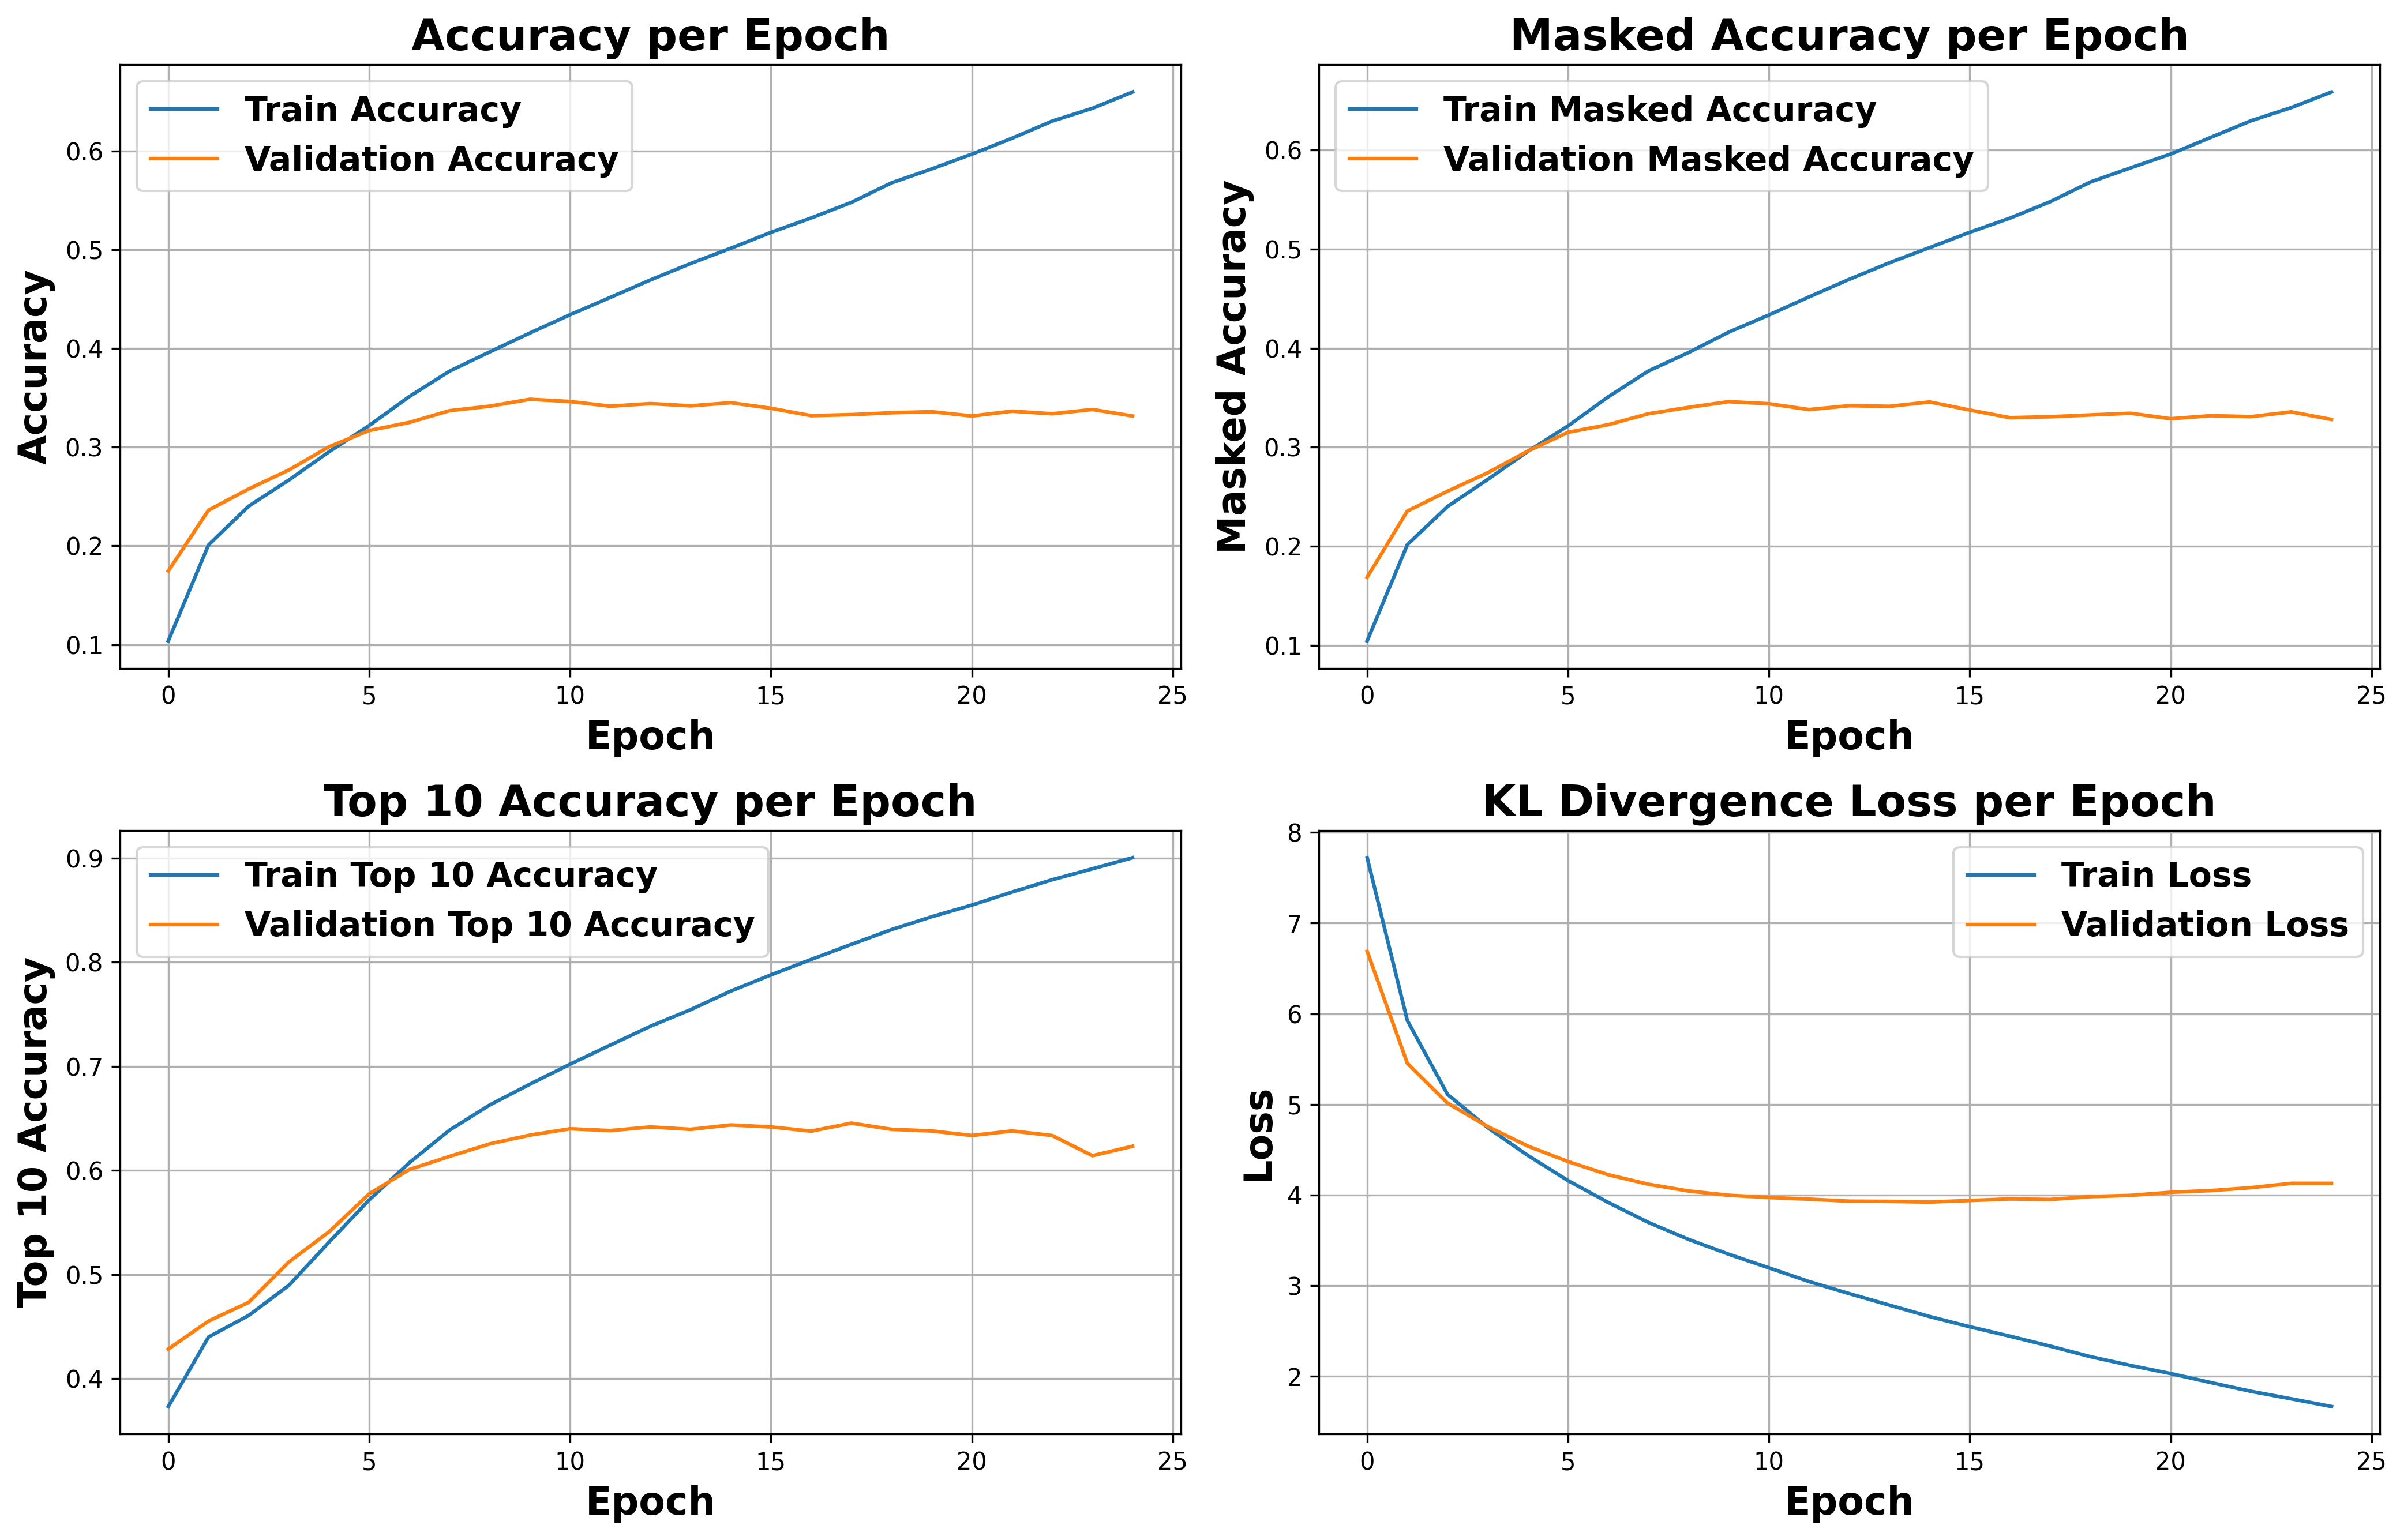

In [8]:
plt.figure(figsize=(14, 9), dpi=300)

plt.subplot(2, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title(f'Accuracy per Epoch', size=18, weight='bold')
plt.xlabel('Epoch', size=16, weight='bold')
plt.ylabel('Accuracy', size=16, weight='bold')
plt.legend(prop={'weight': 'bold', 'size': 14})
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(history.history['masked_acc'], label='Train Masked Accuracy')
plt.plot(history.history['val_masked_acc'], label='Validation Masked Accuracy')
plt.title(f'Masked Accuracy per Epoch', size=18, weight='bold')
plt.xlabel('Epoch', size=16, weight='bold')
plt.ylabel('Masked Accuracy', size=16, weight='bold')
plt.legend(prop={'weight': 'bold', 'size': 14})
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(history.history['top_10_accuracy'], label='Train Top 10 Accuracy')
plt.plot(history.history['val_top_10_accuracy'], label='Validation Top 10 Accuracy')
plt.title(f'Top 10 Accuracy per Epoch', size=18, weight='bold')
plt.xlabel('Epoch', size=16, weight='bold')
plt.ylabel('Top 10 Accuracy', size=16, weight='bold')
plt.legend(prop={'weight': 'bold', 'size': 14})
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title(f'KL Divergence Loss per Epoch', size=18, weight='bold')
plt.xlabel('Epoch', size=16, weight='bold')
plt.ylabel('Loss', size=16, weight='bold')
plt.legend(prop={'weight': 'bold', 'size': 14})
plt.grid(True)

plt.tight_layout()
plt.show()

In [9]:
model.save_weights(os.path.join(OUTPUT_DIR, "model.weights.h5"))
model.save(os.path.join(OUTPUT_DIR, "model.h5"))